# **Microproyecto 1 - Tecnicas de Deep Learning**
**Clasificación de MRI con Redes Neuronales Convolucionales para Tipos de Cáncer**

Omar Diaz / Diego Burbano

### 1. Importacion de Librerias

In [ ]:
# Instalaciones requeridas
!pip install -q kagglehub torch torchvision torchaudio

# Importacion de librerias
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
import random
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from collections import Counter


### 2. Importacion de Imágenes

In [ ]:
# Descargar el dataset
path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")
print("Dataset descargado en:", path)


100%|██████████| 236M/236M [00:01<00:00, 165MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1


In [ ]:
# Inspeccionar el primer nivel de carpetas
for root, dirs, files in os.walk(path):
    print("Subcarpetas:", dirs)
    break


Subcarpetas: ['glioma', 'healthy', 'pituitary', 'meningioma']


In [ ]:
# Carga de datos en las variables X y Y
X = []
Y = []

# Recorrer todas las carpetas dentro de la ruta base
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)

    # Validar que sea una carpeta (no un archivo)
    if os.path.isdir(class_path):
        # Recorrer todas las imágenes dentro de esa carpeta
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            # Guardar la ruta en X y la etiqueta (nombre de la carpeta) en Y
            X.append(img_path)
            Y.append(class_name)

In [ ]:
#Verificar que se hayan cargado correctamente los datos y sus etiquetas
indices = random.sample(range(0, 7023), 10)
for i in indices:
  print(f"Imagen: {X[i]}  -->  Etiqueta: {Y[i]}")

Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/pituitary/0490.jpg  -->  Etiqueta: pituitary
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/glioma/1438.jpg  -->  Etiqueta: glioma
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/pituitary/0813.jpg  -->  Etiqueta: pituitary
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/glioma/1511.jpg  -->  Etiqueta: glioma
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/glioma/0187.jpg  -->  Etiqueta: glioma
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/healthy/1753.jpg  -->  Etiqueta: healthy
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/glioma/0502.jpg  -->  Etiqueta: glioma
Imagen: /root/.cache/kagglehub/datasets/rm1000/brain-tumor-mri-scans/versions/1/meningioma/1045.jpg  -->  Etiqueta: meningioma
Imagen: /root/.cache/kaggl

In [ ]:
#Verificación de balanceo de clases
pd.Series(Y).value_counts()

,count
healthy,2000
pituitary,1757
meningioma,1645
glioma,1621


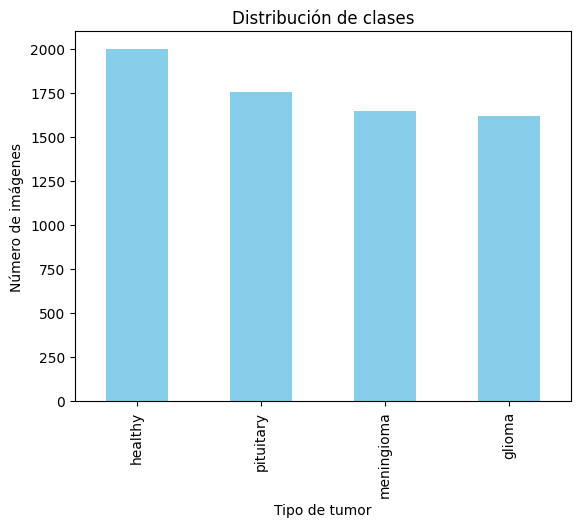

In [ ]:
pd.Series(Y).value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribución de clases")
plt.xlabel("Tipo de tumor")
plt.ylabel("Número de imágenes")
plt.show()

### 3. Transformación de las imágenes, creación de los set de entrenamiento y prueba y preparación de los Tensores para el modelo

In [ ]:
# Codificación de las etiquetas de Y en formato numérico
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

# Visualización de la codificación
for clase in np.unique(Y_encoded):
    print(f"Código {clase}: {encoder.classes_[clase]}")

# Distribución de clases
conteo = Counter(Y_encoded)
print("\nDistribución de clases:", conteo)


Código 0: glioma
Código 1: healthy
Código 2: meningioma
Código 3: pituitary

Distribución de clases: Counter({np.int64(1): 2000, np.int64(3): 1757, np.int64(2): 1645, np.int64(0): 1621})


In [ ]:
# Creación del pipeline de datos
transform_pipeline = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),        # Conversión a escala de grises
    transforms.Resize((150, 150)),                      # Homogeinización de tamaño
    transforms.RandomRotation(degrees=20),              # Data augementation (rotación aleatoria)
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),                              # Convertir a tensor
    transforms.Normalize(mean=[0.5], std=[0.5])        # Escalado a (-1, 1)
])

In [ ]:
# Aplicación de la transformación
X_t = []

for path in X:
    img = Image.open(path)
    img_t = transform_pipeline(img)
    X_t.append(img_t)

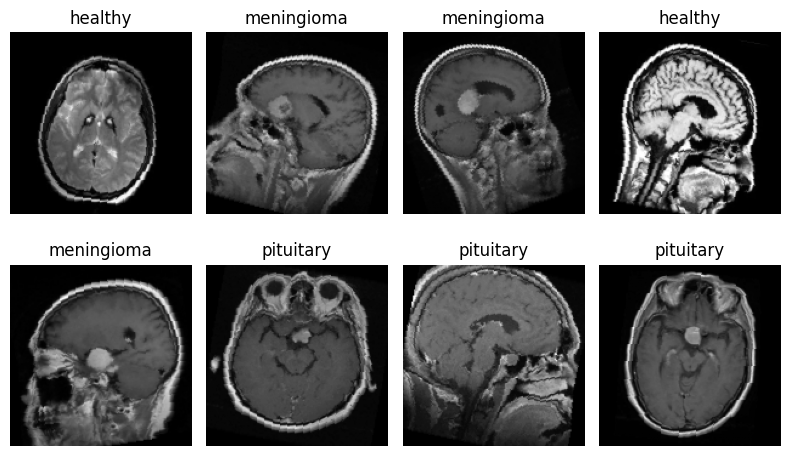

In [ ]:
# Seleccionar 8 índices aleatorios
indices = random.sample(range(len(X_t)), 8)

# Crear figura
fig, axes = plt.subplots(2, 4, figsize=(8, 5))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_t = X_t[idx]

    # Convertir tensor a imagen numpy
    img_np = img_t.squeeze().numpy()

    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(Y[idx])
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Verificación de la normalización
indrand = random.randint(0, len(X_t))
print(X_t[indrand].min(), X_t[indrand].max())

tensor(-0.9922) tensor(0.6941)


In [ ]:
# X_train, X_test, Y_train, Y_test = train_test_split(X_t, Y_encoded, test_size=0.2, stratify = Y, random_state=42)

# Generación de conjunto de TEST (10%)
X_temp, X_test, Y_temp, Y_test = train_test_split(X_t, Y_encoded, test_size=0.10, stratify=Y_encoded, random_state=42)

# Generación de conjuntos de VALIDACION (20%) y TRAIN (70%)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.2222, stratify=Y_temp, random_state=42
)


In [ ]:
print(f"Tamaño del conjunto de entrenamiento (TRAIN): {len(X_train)}")
print(f"Tamaño del conjunto de validación (VAL): {len(X_val)}")
print(f"Tamaño del conjunto de prueba (TEST): {len(X_test)}")

Tamaño del conjunto de entrenamiento (TRAIN): 4915
Tamaño del conjunto de validación (VAL): 1405
Tamaño del conjunto de prueba (TEST): 703


In [ ]:
# Convertir los set de datos a tensores

# Conversión a tensores
X_train_tensor = torch.stack(X_train)  # (n_train, 1, 150, 150)
X_val_tensor = torch.stack(X_val)      # (n_val, 1, 150, 150)
X_test_tensor = torch.stack(X_test)    # (n_test, 1, 150, 150)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

# Confirmación de dimensiones
print(f"Dimensiones de X_train_tensor: {X_train_tensor.shape}")
print(f"Dimensiones de X_val_tensor: {X_val_tensor.shape}")
print(f"Dimensiones de X_test_tensor: {X_test_tensor.shape}")
print(f"Dimensiones de Y_train_tensor: {Y_train_tensor.shape}")
print(f"Dimensiones de Y_val_tensor: {Y_val_tensor.shape}")
print(f"Dimensiones de Y_test_tensor: {Y_test_tensor.shape}")



Dimensiones de X_train_tensor: torch.Size([4915, 1, 150, 150])
Dimensiones de X_val_tensor: torch.Size([1405, 1, 150, 150])
Dimensiones de X_test_tensor: torch.Size([703, 1, 150, 150])
Dimensiones de Y_train_tensor: torch.Size([4915])
Dimensiones de Y_val_tensor: torch.Size([1405])
Dimensiones de Y_test_tensor: torch.Size([703])


In [ ]:
# Creación de los TensorDataset
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   Y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  Y_test_tensor)

# Definición del batch size
batch_size = 32

# Creación de los DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Información general
print(f"Número de batches en train: {len(train_loader)}")
print(f"Número de batches en val:   {len(val_loader)}")
print(f"Número de batches en test:  {len(test_loader)}")



Número de batches en train: 154
Número de batches en val:   44
Número de batches en test:  22


**Configuración del device:**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


###4. Construccion de la CNN

In [ ]:
# Modelo CNN
class CNN_Base(nn.Module):
    def __init__(self, num_classes=4, fc1_features=4096, fc2_features=4096):
        super(CNN_Base, self).__init__()

        # Features
        self.features = nn.Sequential(
            # Conv1
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),  # reduce rápido el tamaño espacial
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Calculo dinamico del número de features que salen de self.features
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 150, 150)   # batch=1, canales=1, H=150, W=150
            feat_out = self.features(dummy)
            n_features = feat_out.view(1, -1).size(1)

        # ---- classifier (fully connected head) ----

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(n_features, fc1_features),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(fc1_features, fc2_features),
            nn.ReLU(inplace=True),
            nn.Linear(fc2_features, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # (batch, n_features)
        x = self.classifier(x)
        return x



In [ ]:
model = CNN_Base(num_classes=4, fc1_features=1024, fc2_features=512).to(device)
print(model)


CNN_Base(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=2304, out_features=1024, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4,

In [ ]:
# Función de pérdida y optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)


In [ ]:
# Bucle de entrenamiento con registro de pérdida y accuracy
epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    # ENTRENAMIENTO
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()               #Reiniciar gradientes
        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        # Backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader) if len(train_loader) > 0 else 0
    train_losses.append(avg_train_loss)

    train_acc = 100 * correct_train / total_train if total_train > 0 else 0
    train_accuracies.append(train_acc)

    # VALIDACION
    model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for images_val, labels_val in val_loader:
            images_val, labels_val = images_val.to(device), labels_val.to(device)
            outputs_val = model(images_val)
            loss = loss_fn(outputs_val, labels_val)
            val_loss += loss.item()

            _, predicted = torch.max(outputs_val, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted == labels_val).sum().item()

    scheduler.step(val_loss)

    avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val if total_val > 0 else 0
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/20] Train Loss: 1.1641 | Train Acc: 44.33% | Val Loss: 1.0758 | Val Acc: 50.60%
Epoch [2/20] Train Loss: 0.8727 | Train Acc: 63.99% | Val Loss: 0.8423 | Val Acc: 66.05%
Epoch [3/20] Train Loss: 0.6716 | Train Acc: 72.19% | Val Loss: 0.6387 | Val Acc: 75.02%
Epoch [4/20] Train Loss: 0.5613 | Train Acc: 77.15% | Val Loss: 0.5690 | Val Acc: 77.30%
Epoch [5/20] Train Loss: 0.4971 | Train Acc: 79.49% | Val Loss: 0.5103 | Val Acc: 79.00%
Epoch [6/20] Train Loss: 0.4499 | Train Acc: 81.08% | Val Loss: 0.4771 | Val Acc: 80.21%
Epoch [7/20] Train Loss: 0.3984 | Train Acc: 83.68% | Val Loss: 0.4297 | Val Acc: 83.27%
Epoch [8/20] Train Loss: 0.3440 | Train Acc: 85.82% | Val Loss: 0.4760 | Val Acc: 82.35%
Epoch [9/20] Train Loss: 0.3047 | Train Acc: 87.91% | Val Loss: 0.5058 | Val Acc: 81.71%
Epoch [10/20] Train Loss: 0.2936 | Train Acc: 88.14% | Val Loss: 0.4118 | Val Acc: 83.49%
Epoch [11/20] Train Loss: 0.2292 | Train Acc: 91.23% | Val Loss: 0.3446 | Val Acc: 87.76%
Epoch [12/20] Train

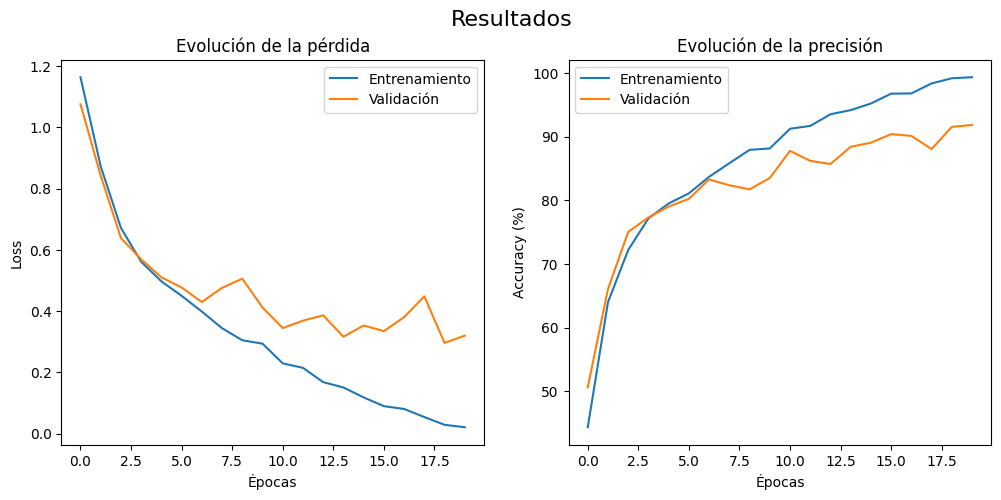

In [ ]:
# Graficar pérdidas y accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Resultados", fontsize=16)

# Gráfica 1: Pérdida
axes[0].plot(train_losses, label="Entrenamiento")
axes[0].plot(val_losses, label="Validación")
axes[0].set_title("Evolución de la pérdida")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Gráfica 2: Accuracy
axes[1].plot(train_accuracies, label="Entrenamiento")
axes[1].plot(val_accuracies, label="Validación")
axes[1].set_title("Evolución de la precisión")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.show()

Resultados en ENTRENAMIENTO:
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00      1135
     healthy       1.00      1.00      1.00      1400
  meningioma       1.00      1.00      1.00      1151
   pituitary       1.00      1.00      1.00      1229

    accuracy                           1.00      4915
   macro avg       1.00      1.00      1.00      4915
weighted avg       1.00      1.00      1.00      4915


 Resultados en EVALUACION:
              precision    recall  f1-score   support

      glioma       0.91      0.88      0.90       324
     healthy       0.96      0.97      0.96       400
  meningioma       0.85      0.86      0.85       329
   pituitary       0.95      0.95      0.95       352

    accuracy                           0.92      1405
   macro avg       0.92      0.91      0.92      1405
weighted avg       0.92      0.92      0.92      1405



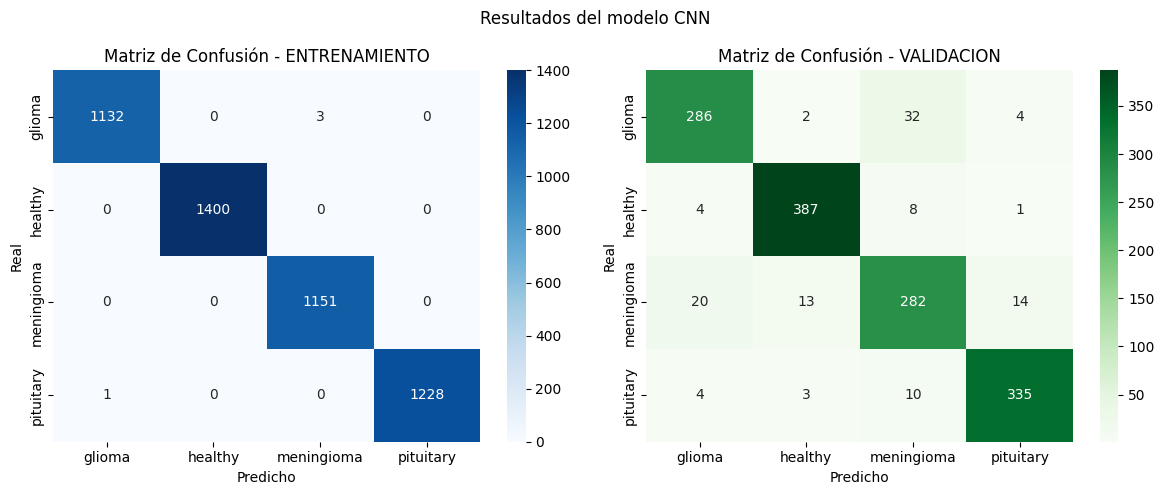

In [ ]:
# === PREDICCIONES Y REPORTES ===
model.eval()

# ENTRENAMIENTO
all_labels_train = []
all_preds_train = []

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_train.extend(labels.cpu().numpy())
        all_preds_train.extend(predicted.cpu().numpy())

# EVALUACION
all_labels_val = []
all_preds_val = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_val.extend(labels.cpu().numpy())
        all_preds_val.extend(predicted.cpu().numpy())

# === REPORTES ===
print("Resultados en ENTRENAMIENTO:")
print(classification_report(all_labels_train, all_preds_train, target_names=encoder.classes_))

print("\n Resultados en EVALUACION:")
print(classification_report(all_labels_val, all_preds_val, target_names=encoder.classes_))

# === MATRICES DE CONFUSIÓN ===
cm_train = confusion_matrix(all_labels_train, all_preds_train)
cm_test = confusion_matrix(all_labels_val, all_preds_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_train, annot=True, cmap="Blues", fmt="g", ax=axes[0],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[0].set_title("Matriz de Confusión - ENTRENAMIENTO")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

sns.heatmap(cm_test, annot=True, cmap="Greens", fmt="g", ax=axes[1],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[1].set_title("Matriz de Confusión - VALIDACION")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.suptitle("Resultados del modelo CNN")
plt.tight_layout()
plt.show()



📊 Resultados en Test:
Test Loss: 0.4031 | Test Accuracy: 92.32%


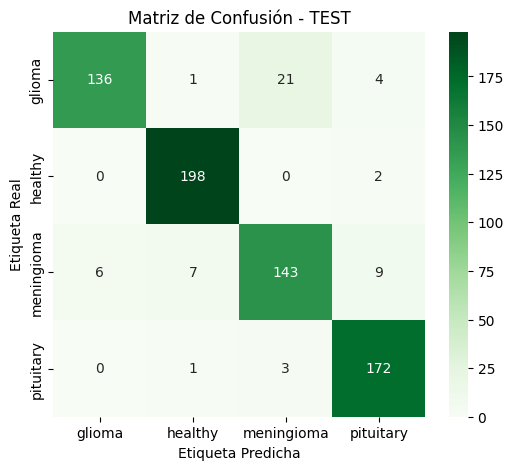


Reporte de clasificación:
              precision    recall  f1-score   support

      glioma       0.96      0.84      0.89       162
     healthy       0.96      0.99      0.97       200
  meningioma       0.86      0.87      0.86       165
   pituitary       0.92      0.98      0.95       176

    accuracy                           0.92       703
   macro avg       0.92      0.92      0.92       703
weighted avg       0.92      0.92      0.92       703



In [ ]:
# EVALUACIÓN EN TEST
model.eval()
test_loss = 0.0
correct_test, total_test = 0, 0
all_labels, all_preds = [], []

with torch.no_grad():
    for images_test, labels_test in test_loader:
        images_test, labels_test = images_test.to(device), labels_test.to(device)
        outputs_test = model(images_test)
        loss = loss_fn(outputs_test, labels_test)
        test_loss += loss.item()

        _, predicted = torch.max(outputs_test, 1)
        total_test += labels_test.size(0)
        correct_test += (predicted == labels_test).sum().item()

        all_labels.extend(labels_test.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = 100 * correct_test / total_test

print(f"\n📊 Resultados en Test:")
print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(all_labels, all_preds)
class_names = ['glioma', 'healthy', 'meningioma', 'pituitary']  # Ajusta según tus clases

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - TEST")
plt.ylabel("Etiqueta Real")
plt.xlabel("Etiqueta Predicha")
plt.show()

# REPORTE DE CLASIFICACIÓN
print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=class_names))
